## Ejercicio Regresión Polinómica 2

Usando los ejemplos hechos en clase debes resolver el problema que se plantea a continuación.

Usando los datos de casos confirmados de COVID-19 en el mundo frente a los días pasados desde que empezó la pandemia, haz el mejor predictor posible.



In [1]:
#Empezamos preparando los datos. Vamos a generar un dataframe con los días desde el comienzo de la 
#pandemia y el número de casos confirmados.

import pandas as pd

df_covid = pd.read_csv("time_series_covid19_confirmed_global.csv")
df_covid.head()

,Province/State,Country/Region,Lat,Long,1/22/20,1/23/20,1/24/20,1/25/20,1/26/20,1/27/20,...,2/19/22,2/20/22,2/21/22,2/22/22,2/23/22,2/24/22,2/25/22,2/26/22,2/27/22,2/28/22
0,NaN,Afghanistan,33.93911,67.709953,0,0,0,0,0,0,...,171931,172205,172441,172716,172901,173047,173084,173146,173395,173659
1,NaN,Albania,41.15330,20.168300,0,0,0,0,0,0,...,269904,270164,270370,270455,270734,270947,271141,271141,271527,271563
2,NaN,Algeria,28.03390,1.659600,0,0,0,0,0,0,...,263936,264054,264201,264365,264488,264603,264706,264778,264855,264936
3,NaN,Andorra,42.50630,1.521800,0,0,0,0,0,0,...,37589,37589,37589,37820,37901,37958,37999,37999,37999,37999
4,NaN,Angola,-11.20270,17.873900,0,0,0,0,0,0,...,98617,98638,98658,98671,98698,98701,98701,98701,98701,98741


In [2]:
df_covid_limpio = df_covid.drop(["Province/State", "Country/Region", "Lat", "Long"], axis=1)
df_covid_limpio.head()

,1/22/20,1/23/20,1/24/20,1/25/20,1/26/20,1/27/20,1/28/20,1/29/20,1/30/20,1/31/20,...,2/19/22,2/20/22,2/21/22,2/22/22,2/23/22,2/24/22,2/25/22,2/26/22,2/27/22,2/28/22
0,0,0,0,0,0,0,0,0,0,0,...,171931,172205,172441,172716,172901,173047,173084,173146,173395,173659
1,0,0,0,0,0,0,0,0,0,0,...,269904,270164,270370,270455,270734,270947,271141,271141,271527,271563
2,0,0,0,0,0,0,0,0,0,0,...,263936,264054,264201,264365,264488,264603,264706,264778,264855,264936
3,0,0,0,0,0,0,0,0,0,0,...,37589,37589,37589,37820,37901,37958,37999,37999,37999,37999
4,0,0,0,0,0,0,0,0,0,0,...,98617,98638,98658,98671,98698,98701,98701,98701,98701,98741


In [3]:
dias = []
cuenta_total = []

for i, col in enumerate(df_covid_limpio.columns, start=1):
    dias.append(col)  
    cuenta_total.append(df_covid_limpio[col].sum()) 

print(dias)
print(cuenta_total)


['1/22/20', '1/23/20', '1/24/20', '1/25/20', '1/26/20', '1/27/20', '1/28/20', '1/29/20', '1/30/20', '1/31/20', '2/1/20', '2/2/20', '2/3/20', '2/4/20', '2/5/20', '2/6/20', '2/7/20', '2/8/20', '2/9/20', '2/10/20', '2/11/20', '2/12/20', '2/13/20', '2/14/20', '2/15/20', '2/16/20', '2/17/20', '2/18/20', '2/19/20', '2/20/20', '2/21/20', '2/22/20', '2/23/20', '2/24/20', '2/25/20', '2/26/20', '2/27/20', '2/28/20', '2/29/20', '3/1/20', '3/2/20', '3/3/20', '3/4/20', '3/5/20', '3/6/20', '3/7/20', '3/8/20', '3/9/20', '3/10/20', '3/11/20', '3/12/20', '3/13/20', '3/14/20', '3/15/20', '3/16/20', '3/17/20', '3/18/20', '3/19/20', '3/20/20', '3/21/20', '3/22/20', '3/23/20', '3/24/20', '3/25/20', '3/26/20', '3/27/20', '3/28/20', '3/29/20', '3/30/20', '3/31/20', '4/1/20', '4/2/20', '4/3/20', '4/4/20', '4/5/20', '4/6/20', '4/7/20', '4/8/20', '4/9/20', '4/10/20', '4/11/20', '4/12/20', '4/13/20', '4/14/20', '4/15/20', '4/16/20', '4/17/20', '4/18/20', '4/19/20', '4/20/20', '4/21/20', '4/22/20', '4/23/20', '4/

In [11]:
cuenta_total = df_covid_limpio.sum()  
dias = list(range(1, len(cuenta_total)+1))  
cuenta_total = cuenta_total.tolist()

df_casos_diarios = pd.DataFrame({
    "dia": dias, 
    "casos_diarios": cuenta_total
})

print(dias)
print(cuenta_total)
print(len(dias))
print(len(cuenta_total))

[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 181, 182, 183, 184, 185, 186, 187, 188, 189, 190, 191, 192, 193, 194, 195, 196, 197, 198, 199, 200, 201, 202, 203, 204, 205, 206, 207, 208, 209, 210, 211, 212, 213, 214, 215, 216, 217, 218, 219, 220, 221, 22

In [12]:
df_casos_diarios.head()

,dia,casos_diarios
0,1,557
1,2,655
2,3,941
3,4,1434
4,5,2118


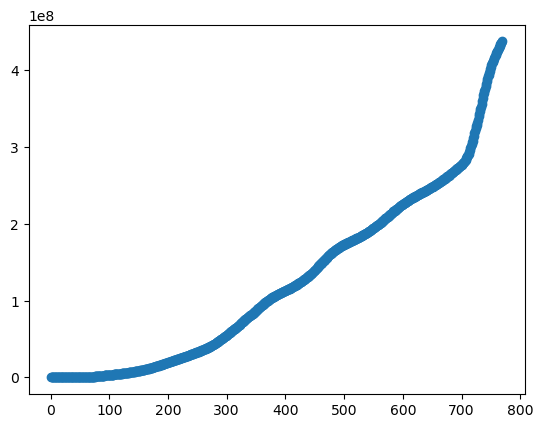

In [14]:
import matplotlib.pyplot as plt

plt.scatter(x=dias, y=cuenta_total)
plt.show()

In [6]:
#Preparamos X e y

X = df_casos_diarios["dia"].to_frame()
y = df_casos_diarios["casos_diarios"].to_frame()

print(X.shape)
print(y.shape)

(769, 1)
(769, 1)


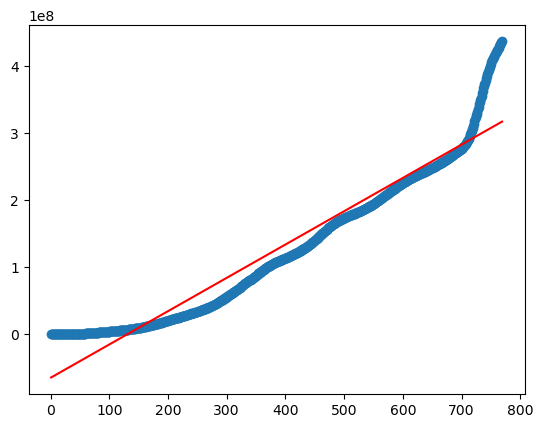

In [ ]:
#Probamos con regresion lineal para ver como se ajusta la recta

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 0)


from sklearn.linear_model import LinearRegression
lm = LinearRegression()
lm.fit(X_train, y_train)

y_pred = lm.predict(X_test)

y_pred_total = lm.predict(X)

plt.scatter(X, y)
plt.plot(X,y_pred_total,color='red')
plt.show()

In [8]:
#Vamos a probar con un polinomio de grado 2:

from sklearn.preprocessing import PolynomialFeatures
poly_features = PolynomialFeatures(degree=2,include_bias=False)
X_poly = poly_features.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(X_poly, y, test_size = 0.2, random_state = 0)


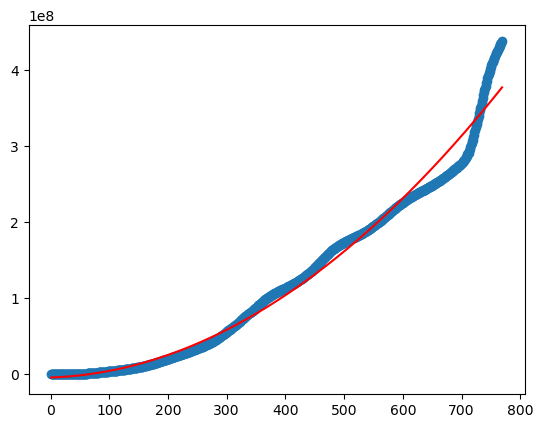

In [9]:
#Veamos que tal se ajusta a la curva:

# Mostrando gráfica con el polinomio de grado 2:
lm = LinearRegression()
lm.fit(X_train, y_train)

y_pred_total = lm.predict(X_poly)
plt.scatter(X, y)
plt.plot(X,y_pred_total,color='red')
plt.show() 

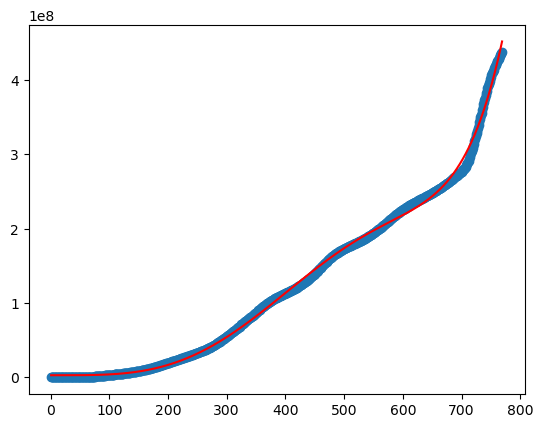

In [10]:
#Probemos ahora con un grado superior:

from sklearn.preprocessing import PolynomialFeatures
poly_features = PolynomialFeatures(degree=7,include_bias=False)
X_poly = poly_features.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(X_poly, y, test_size = 0.2, random_state = 0)

# Mostrando gráfica con el polinomio de grado 2:
lm = LinearRegression()
lm.fit(X_train, y_train)

y_pred_total = lm.predict(X_poly)
plt.scatter(X, y)
plt.plot(X,y_pred_total,color='red')
plt.show() 